In [5]:
import pandas as pd
df_raw = pd.DataFrame({'var1':[1,2,1],
             'var2': [2,3,2]})
df_new = df_raw.copy()
df_new = df_new.rename(columns={'var2':'v2'})

print(df_raw)
print(df_new)

   var1  var2
0     1     2
1     2     3
2     1     2
   var1  v2
0     1   2
1     2   3
2     1   2


다른 방법의 평균 : 20.14957264957265


count    234.000000
mean      20.149573
std        5.050290
min       10.500000
25%       15.500000
50%       20.500000
75%       23.500000
max       39.500000
Name: total, dtype: float64

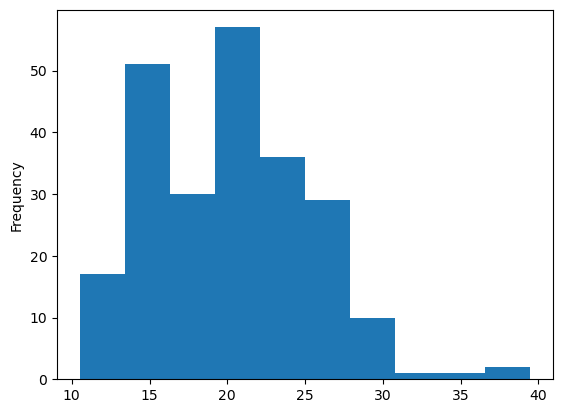

In [21]:
import pandas as pd

df_mpg = pd.read_csv('mpg.csv')
df_mpg['total'] = (df_mpg['cty'] + df_mpg['hwy']) / 2 
print(f'다른 방법의 평균 : {df_mpg['total'].mean()}')

df_mpg['total'].plot.hist()
df_mpg['total'].describe()


In [17]:
import pandas as pd
df_mpg = pd.read_csv('mpg.csv')
mpg_new = df_mpg.copy() #1
mpg_new = mpg_new.rename(columns={'cty':'city','hwy':'highway'})#2
mpg_new.to_csv('new_mpg.csv')


In [2]:
import pandas as pd
df = pd.DataFrame({'var1': [4,3,8],'var2' : [2,6,1]})
df['var_sum'] = df['var1'] + df['var2']
df['var_mean'] = df['var_sum'] / 2
df

,var1,var2,var_sum,var_mean
0,4,2,6,3.0
1,3,6,9,4.5
2,8,1,9,4.5


In [34]:
import pandas as pd
import numpy as np

mpg = pd.read_csv('mpg.csv')
mpg['total'] = (mpg['cty'] + mpg['hwy']) / 2
mpg['test'] = np.where(mpg['total'] >= 20 , 'pass','fail')# 20이상이면 pass, 아니면 fail
mpg['grade'] = np.where(mpg['total'] >= 30, 'A',# 30이상이면 'A', 20이상이면 'B' 그것도 아니면 'C'
                       np.where(mpg['total'] >= 20, 'B','C'))
mpg['size'] = np.where(mpg['category'].isin(['compact','subcompact','2seater']),'small','large')# isin() 에 모두 해당되면
mpg['size'].value_counts()

size
large    147
small     87
Name: count, dtype: int64

In [64]:
# 130p 분석도전. midwest.csv를 이용
# 1. 데이터의 특징파악
import pandas as pd
import numpy as np
df_mdwest = pd.read_csv('midwest.csv')
'''
df_mdwest.shape
df_mdwest.head()
df_mdwest.tail()
df_mdwest.info()
df_mdwest.describe()
'''
#2. poptotal(전체인구)변수를 total로 , popasian(아시안)을 asian으로 바꾼다

df_mdwest = df_mdwest.rename(columns={'poptotal':'total','popasian':'asian'})

#3. total, asian변수를 이용해 전체 인구대비 아시아 인구 백분율 파생변수 추가, 히스토그램으로 표현
df_mdwest['asian_rate'] = df_mdwest['asian'] / df_mdwest['total'] * 100
#df_mdwest['asian_rate'].plot.hist()

#4. 인구 백분율 전체 평균을 구하고, 평균 초과화면 'large' 그이외에는 'small'분류

df_mdwest['asian_ave'] = df_mdwest['asian_rate'].mean()
df_mdwest
#df_mdwest['asian_ave'].plot.hist()
#df_mdwest['asian_ave']
# df_mdwest['asian_size'] = np.where(df_mdwest['asian_rate'] > df_mdwest['asian_ave'], 'large','small')
# df_mdwest['asian_size']

,PID,county,state,area,total,popdensity,popwhite,popblack,popamerindian,asian,...,poppovertyknown,percpovertyknown,percbelowpoverty,percchildbelowpovert,percadultpoverty,percelderlypoverty,inmetro,category,asian_rate,asian_ave
0,561,ADAMS,IL,0.052,66090,1270.961540,63917,1702,98,249,...,63628,96.274777,13.151443,18.011717,11.009776,12.443812,0,AAR,0.376759,0.487246
1,562,ALEXANDER,IL,0.014,10626,759.000000,7054,3496,19,48,...,10529,99.087145,32.244278,45.826514,27.385647,25.228976,0,LHR,0.451722,0.487246
2,563,BOND,IL,0.022,14991,681.409091,14477,429,35,16,...,14235,94.956974,12.068844,14.036061,10.852090,12.697410,0,AAR,0.106731,0.487246
3,564,BOONE,IL,0.017,30806,1812.117650,29344,127,46,150,...,30337,98.477569,7.209019,11.179536,5.536013,6.217047,1,ALU,0.486918,0.487246
4,565,BROWN,IL,0.018,5836,324.222222,5264,547,14,5,...,4815,82.505140,13.520249,13.022889,11.143211,19.200000,0,AAR,0.085675,0.487246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,3048,WAUKESHA,WI,0.034,304715,8962.205880,298313,1096,672,2699,...,299802,98.387674,3.121060,3.785820,2.590061,4.085479,1,HLU,0.885746,0.487246
433,3049,WAUPACA,WI,0.045,46104,1024.533330,45695,22,125,92,...,44412,96.330036,8.488697,10.071411,6.953799,10.338641,0,AAR,0.199549,0.487246
434,3050,WAUSHARA,WI,0.037,19385,523.918919,19094,29,70,43,...,19163,98.854785,13.786985,20.050708,11.695784,11.804558,0,AAR,0.221821,0.487246
435,3051,WINNEBAGO,WI,0.035,140320,4009.142860,136822,697,685,1728,...,133950,95.460376,8.804031,10.592031,8.660587,6.661094,1,HAU,1.231471,0.487246
